# Ceridwen photometry and spectrum fit

- Fit one passive galaxy using both complementary datasets.

## Setup

- Use one Ceridwen kernel identifier on both machines.
- Run bounded CPU trials and full Vast.ai GPU fits.
- Keep a shorter mode for reproducible smoke testing.

In [1]:
#%env CERIDWEN_NOTEBOOK_QUICK=1

In [2]:
import os
from pathlib import Path

os.environ["JAX_ENABLE_X64"] = "1"

import astropy.units as u
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.constants import c
from astropy.io import fits
from astropy.table import Table
from ceridwen.cosmology import age_gyr, flux_factor_maggies
from ceridwen.csp import CSPBasis_afe
from ceridwen.likelihood import (
    DiagonalGaussianLikelihood,
    DiagonalNoiseModel,
    MultiObservationLikelihood,
)
from ceridwen.model import SedModel, logsfr_ratios_to_sfh
from ceridwen.observation import Photometry, Spectrum
from ceridwen.sampler import run_sampler
from ceridwen.sampler.nested import BlackJAXNestedSamplerAdapter
from ceridwen.sampler.priors import Uniform
from ceridwen.ssps import SSPDataAfe
from scipy.special import softmax
from scipy.stats import entropy
from specutils.utils.wcs_utils import air_to_vac

jax.config.update("jax_enable_x64", True)
JAX_DEVICES = jax.devices()
GPU_AVAILABLE = any(device.platform == "gpu" for device in JAX_DEVICES) # true if any gpu is available

SEED = 20260812
QUICK_TEST = os.environ.get("CERIDWEN_NOTEBOOK_QUICK") == "1" # checks env variable to decide on fast vs full run
RUN_PROFILE = "quick" if QUICK_TEST else ("gpu-full" if GPU_AVAILABLE else "cpu-trial")
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

## Data

- Read immutable LEGA-C and matched COSMOS2015 catalogues.
- Load the selected object's public one-dimensional spectrum.

In [3]:
LEGAC_PATH = PROJECT_ROOT / "data/raw/legac_dr2/legaCdr2.fits.gz"
PHOT_PATH = (
    PROJECT_ROOT / "data/raw/cosmos2015/cosmos2015_legac_dr2_photometry_1arcsec.fits"
)
SPECTRA_DIR = PROJECT_ROOT / "data/raw/legac_dr2/sp"

legac = Table.read(LEGAC_PATH) # loads data into astropy table
phot = Table.read(PHOT_PATH)

assert len(legac) == 1988
assert len(np.unique(phot["LEGAC_INDEX"])) == len(phot) # left -> number of distinct values in LEGAC_INDEX column
# verifies phot is unique
assert np.max(phot["MATCH_SEP_ARCSEC"]) < 1.0

## Passive selection

- Apply identical quality, NUVrJ, and emission-line filters.
- Require clean twelve-band photometry for joint fitting.

In [4]:
legac_frame = legac.to_pandas()
for text_column in ["SPECT_ID", "Filename"]:
    legac_frame[text_column] = legac_frame[text_column].map(
        lambda value: value.decode() if isinstance(value, bytes) else value
    )
phot_frame = phot.to_pandas().set_index("LEGAC_INDEX")
phot_columns = [
    "Area",
    "Sat",
    "Cfl",
    "Deep",
    "Flag",
    "E(B-V)",
    "NUVMag",
    "RMag",
    "JMag",
    "Fuap3",
    "e_Fuap3",
    "FBap3",
    "e_FBap3",
    "FVap3",
    "e_FVap3",
    "Frap3",
    "e_Frap3",
    "Fipap3",
    "e_Fipap3",
    "Fzppap3",
    "e_Fzppap3",
    "FYap3",
    "e_FYap3",
    "FJap3",
    "e_FJap3",
    "FHap3",
    "e_FHap3",
    "FKsap3",
    "e_FKsap3",
    "F3.6um",
    "e_F3.6um",
    "F4.5um",
    "e_F4.5um",
]
parent = legac_frame.join(phot_frame[phot_columns], how="inner")

quality = (
    (parent["f_use"] == 1)
    & (parent["f_ppxf"] == 0)
    & (parent["f_z"] == 0)
    & (parent["f_int"] == 0)
    & (parent["SN"] > 0)
    & (parent["z"] >= 0.6)
    & (parent["z"] < 1.0)
)
valid_rest_magnitudes = (parent[["NUVMag", "RMag", "JMag"]] > -40).all(axis=1)
parent = parent[quality & valid_rest_magnitudes].copy()

nuv_r = parent["NUVMag"] - parent["RMag"]
r_j = parent["RMag"] - parent["JMag"]
nuvrj = (nuv_r > 3 * r_j + 1) & (nuv_r > 3.1)
photometric_passive = parent[nuvrj]

oii_ew = photometric_passive["OII_3727_EW"]
weak_oii = photometric_passive[(oii_ew > -5) | oii_ew.isna()]
oii_significance = (weak_oii["OII_3727_EW"] / weak_oii["OII_3727_EW_err"]).abs()
oiii_significance = (weak_oii["OIII_5007_EW"] / weak_oii["OIII_5007_EW_err"]).abs()
bona_fide_passive = weak_oii[~((oii_significance >= 3) | (oiii_significance >= 3))]

clean_photometry = (
    (bona_fide_passive["Area"] == 0)
    & (bona_fide_passive["Sat"] == 0)
    & (bona_fide_passive["Cfl"] == 1)
    & (bona_fide_passive["Flag"] == 0)
)
usable_passive = bona_fide_passive[clean_photometry]

selection_counts = pd.Series(
    {
        "matched primary spectra": len(parent),
        "NUVrJ passive": len(photometric_passive),
        "weak [OII]": len(weak_oii),
        "bona-fide passive": len(bona_fide_passive),
        "clean twelve-band photometry": len(usable_passive),
    }
)
display(selection_counts.to_frame("count"))

,count
matched primary spectra,1328
NUVrJ passive,609
weak [OII],454
bona-fide passive,349
clean twelve-band photometry,194


## Shared target

- Keep M1_210210 for direct notebook-to-notebook comparison.
- Fix redshift and stellar dispersion from LEGA-C measurements.

In [5]:
def load_spectrum(filename):
    if isinstance(filename, bytes):
        filename = filename.decode()
    with fits.open(SPECTRA_DIR / filename) as hdulist:
        spectrum = hdulist[1].data
        instrument_resolution = float(hdulist[0].header["SPEC_RES"])
    wave, flux, error, quality_flag = (
        spectrum[column][0] for column in ("WAVE", "FLUX", "ERR", "QUAL")
    )
    good = (quality_flag == 0) & (error > 0) & np.isfinite(flux)
    return wave, flux, error, good, instrument_resolution


target_rows = usable_passive[usable_passive["SPECT_ID"] == "M1_210210"]
assert len(target_rows) == 1
galaxy = target_rows.iloc[0]
wave_air, flux_dr2, error_dr2, good_pixel, instrument_fwhm_resolution = (
    load_spectrum(galaxy["Filename"])
)

z_catalog = float(galaxy["z"])
sigma_star = float(galaxy["SIGMA_STARS_PRIME"])
observed_break = 4000 * (1 + z_catalog)
assert wave_air[good_pixel].min() < observed_break < wave_air[good_pixel].max()

print(f"{galaxy['SPECT_ID']}  z={z_catalog:.4f}")
print(f"catalogue S/N={galaxy['SN']:.1f}")
print(f"fixed sigma*={sigma_star:.1f} km/s")
print(f"instrument FWHM resolving power={instrument_fwhm_resolution:.0f}")
print(
    f"good spectral coverage: {wave_air[good_pixel].min():.0f}-"
    f"{wave_air[good_pixel].max():.0f} angstrom"
)

M1_210210  z=0.6542
catalogue S/N=62.2
fixed sigma*=259.5 km/s
instrument FWHM resolving power=2500
good spectral coverage: 6190-8633 angstrom


## Photometric observation

- Convert twelve three-arcsecond fluxes from microjansky into maggies.
- Add the same five-percent photometric uncertainty floor.
- Reserve Subaru i+ exclusively for aperture anchoring.

In [6]:
FILTER_NAMES = [
    "cfht_megacam_us_9301",
    "subaru_suprimecam_B",
    "subaru_suprimecam_V",
    "subaru_suprimecam_rp",
    "subaru_suprimecam_ip",
    "subaru_suprimecam_zp",
    "vista_vircam_Y",
    "vista_vircam_J",
    "vista_vircam_H",
    "vista_vircam_Ks",
    "spitzer_irac_ch1",
    "spitzer_irac_ch2",
]
FLUX_COLUMNS = [
    "Fuap3",
    "FBap3",
    "FVap3",
    "Frap3",
    "Fipap3",
    "Fzppap3",
    "FYap3",
    "FJap3",
    "FHap3",
    "FKsap3",
    "F3.6um",
    "F4.5um",
]
ERROR_COLUMNS = [f"e_{name}" for name in FLUX_COLUMNS]
UJY_TO_MAGGIES = 1e-6 / 3631.0
CGS_FNU_PER_MAGGIE = 3631e-23
PHOTOMETRY_FLOOR = 0.05
I_FILTER_INDEX = FILTER_NAMES.index("subaru_suprimecam_ip")

phot_flux = galaxy[FLUX_COLUMNS].to_numpy(dtype=float) * UJY_TO_MAGGIES
phot_error_stat = galaxy[ERROR_COLUMNS].to_numpy(dtype=float) * UJY_TO_MAGGIES
phot_uncertainty = np.hypot(
    phot_error_stat,
    PHOTOMETRY_FLOOR * np.abs(phot_flux),
)
phot_mask = np.isfinite(phot_flux) & np.isfinite(phot_uncertainty) & (phot_flux > 0)
phot_fit_mask = phot_mask.copy()
phot_fit_mask[I_FILTER_INDEX] = False

assert phot_mask.all()
assert phot_fit_mask.sum() == 11
phot_obs = Photometry(
    filters=FILTER_NAMES,
    flux=phot_flux,
    uncertainty=phot_uncertainty,
    mask=phot_fit_mask,
    name="photometry",
)
phot_obs.display()

Photometry (photometry)
  n_filters     : 12
  ndof          : 11
  wave_eff range: 3813 – 44781 Å
  filters       : cfht_megacam_us_9301, subaru_suprimecam_B, subaru_suprimecam_V, subaru_suprimecam_rp, subaru_suprimecam_ip … (+7 more)
  masked filters: 1 / 12

  #    filter                           λ_eff [Å]      flux [mag]             σ      S/N   mask   UL
  --------------------------------------------------------------------------------------------------
  0    cfht_megacam_us_9301                3813.2      9.9146e-11    1.0352e-11     9.58   True    -
  1    subaru_suprimecam_B                 4427.2      2.3134e-10    1.4215e-11    16.27   True    -
  2    subaru_suprimecam_V                 5454.9      1.2421e-09    6.7937e-11    18.28   True    -
  3    subaru_suprimecam_rp                6249.0      2.5034e-09    1.2879e-10    19.44   True    -
  4    subaru_suprimecam_ip                7645.9      6.7888e-09    3.4162e-10    19.87  False    -
  5    subaru_suprimecam_zp    

## Spectroscopic observation

- Convert the LEGA-C spectrum into observed-frame F-nu.
- Match its continuum scale to observed Subaru (i^+).
- Retain native pixels with instrument and stellar broadening.

Spectrum (spectrum)
  ndata         : 6166
  ndof          : 3523
  wavelength    : 5801.9 – 9501.9 Å
  resolution    : R = 5887.1
  smoothtype    : R
  sigma_losvd   : 259.5 km/s
  logify        : False
  calibration   : none
  sky           : none
  noise_floor   : 0.0000
  noise model   : none
  masked pixels : 2643 / 6166

  i              λ [Å]            flux               σ   mask
  -----------------------------------------------------------
  0            5801.91      0.0000e+00      1.0000e+00  False
  1            5802.51      0.0000e+00      1.0000e+00  False
  2            5803.11      0.0000e+00      1.0000e+00  False
  3            5803.71      0.0000e+00      1.0000e+00  False
  4            5804.31      0.0000e+00      1.0000e+00  False
  5            5804.91      0.0000e+00      1.0000e+00  False
  6            5805.51      0.0000e+00      1.0000e+00  False
  7            5806.11      0.0000e+00      1.0000e+00  False
  8            5806.71      0.0000e+00      1.0000e

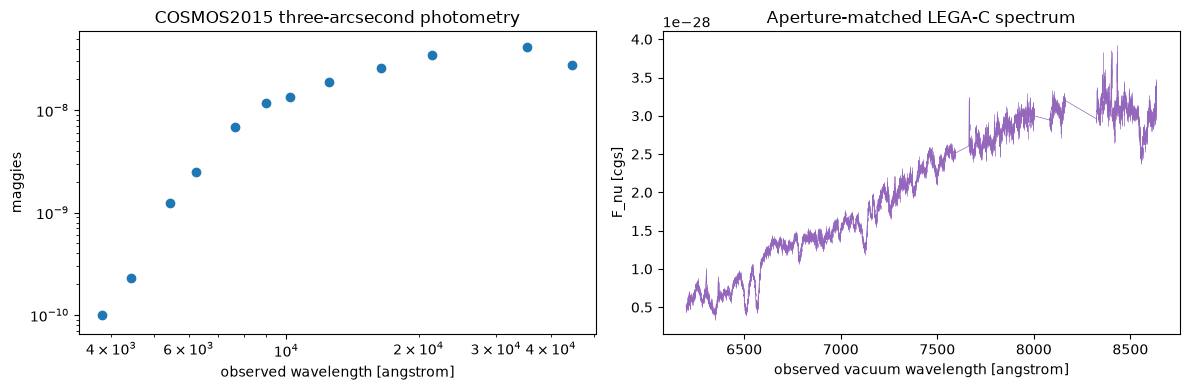

In [7]:
DR2_FLUX_UNIT = 1e-19 * u.erg / u.s / u.cm**2 / u.AA
SPECTRUM_CALIBRATION_INIT = 0.03
FWHM_TO_SIGMA = 2 * np.sqrt(2 * np.log(2))
C3K_FWHM_RESOLUTION = 3000.0
REST_EMISSION_LINES = [3726.0, 3728.8, 4861.3, 4958.9, 5006.8]


def flam_to_fnu_cgs(values, wavelength):
    f_lambda = values * DR2_FLUX_UNIT
    return f_lambda.to_value(
        u.erg / u.s / u.cm**2 / u.Hz,
        equivalencies=u.spectral_density(wavelength * u.AA),
    )


wave_vacuum = air_to_vac(wave_air * u.AA).to_value(u.AA)
native_flux = flam_to_fnu_cgs(flux_dr2, wave_vacuum)
native_uncertainty = flam_to_fnu_cgs(error_dr2, wave_vacuum)

telluric_vacuum = air_to_vac(np.array([7590.0, 7660.0]) * u.AA).to_value(u.AA)
anchor_good = good_pixel & np.isfinite(native_flux) & np.isfinite(native_uncertainty)
anchor_good &= ~(
    (wave_vacuum >= telluric_vacuum[0]) & (wave_vacuum <= telluric_vacuum[1])
)
for rest_wavelength in REST_EMISSION_LINES:
    line_center = rest_wavelength * (1 + z_catalog)
    velocity_offset = np.abs(wave_vacuum - line_center) / line_center * 299792.458
    anchor_good &= velocity_offset > 1500.0

anchor_flux = np.interp(
    wave_vacuum,
    wave_vacuum[anchor_good],
    native_flux[anchor_good],
)
anchor_uncertainty = np.interp(
    wave_vacuum,
    wave_vacuum[anchor_good],
    native_uncertainty[anchor_good],
)
i_anchor = Photometry(
    filters=["subaru_suprimecam_ip"],
    name="i_anchor",
)
i_filter = i_anchor.filterset.filters[0]
assert wave_vacuum[anchor_good].min() < float(i_filter.blue_edge)
assert wave_vacuum[anchor_good].max() > float(i_filter.red_edge)

anchor_spectrum = Spectrum(
    wavelength=wave_vacuum,
    flux=anchor_flux,
    uncertainty=anchor_uncertainty,
    name="anchor_spectrum",
)
synthetic_i_flux = float(
    np.asarray(anchor_spectrum.synthetic_photometry(i_anchor.filterset))
)
aperture_transfer = phot_flux[I_FILTER_INDEX] / synthetic_i_flux
assert np.isfinite(aperture_transfer) and aperture_transfer > 0

scaled_native_flux = aperture_transfer * native_flux
scaled_native_uncertainty = aperture_transfer * native_uncertainty
native_valid = (
    good_pixel
    & np.isfinite(scaled_native_flux)
    & np.isfinite(scaled_native_uncertainty)
    & (scaled_native_uncertainty > 0)
)
spectrum_wave = wave_vacuum
spectrum_flux = np.nan_to_num(scaled_native_flux, nan=0.0)
spectrum_uncertainty = np.where(
    native_valid, scaled_native_uncertainty, 1.0
)
spectrum_obs = Spectrum(
    wavelength=spectrum_wave,
    flux=spectrum_flux,
    uncertainty=spectrum_uncertainty,
    mask=native_valid,
    resolution=instrument_fwhm_resolution * FWHM_TO_SIGMA,
    smoothtype="R",
    inres=c.to_value(u.km / u.s) / (C3K_FWHM_RESOLUTION * FWHM_TO_SIGMA),
    sigma_losvd=sigma_star,
    name="spectrum",
)
spectrum_obs.mask_lines(
    REST_EMISSION_LINES,
    dv=1500.0,
    zred=z_catalog,
)
spectrum_obs.mask_wavelength_range(*telluric_vacuum)
spectrum_mask = np.asarray(spectrum_obs.mask)

assert spectrum_obs.ndof > 3000

spectrum_obs.display()
print(f"synthetic LEGA-C i+ flux: {synthetic_i_flux:.4e} maggies")
print(f"COSMOS2015 i+ flux: {phot_flux[I_FILTER_INDEX]:.4e} maggies")
print(f"fixed photometry/spectrum transfer: {aperture_transfer:.4f}")
print("joint photometric bands: 11; i+ reserved as aperture anchor")
print(f"native good pixels: {good_pixel.sum()}")
print(f"fitted native pixels: {spectrum_obs.ndof}")
print(f"C3K_HR optical FWHM resolution: R={C3K_FWHM_RESOLUTION:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(
    np.asarray(phot_obs.wave_eff),
    phot_flux,
    yerr=phot_uncertainty,
    fmt="o",
    color="tab:blue",
)
axes[0].set(
    xscale="log",
    yscale="log",
    xlabel="observed wavelength [angstrom]",
    ylabel="maggies",
)
axes[0].set_title("COSMOS2015 three-arcsecond photometry")
axes[1].errorbar(
    spectrum_wave[spectrum_mask],
    spectrum_flux[spectrum_mask],
    yerr=spectrum_uncertainty[spectrum_mask],
    fmt="-",
    lw=0.5,
    color="tab:purple",
)
axes[1].set(
    xlabel="observed vacuum wavelength [angstrom]",
    ylabel="F_nu [cgs]",
)
axes[1].set_title("Aperture-matched LEGA-C spectrum")
plt.tight_layout()
plt.show()

## Stellar-population grid

- Use the local alpha-enhanced C3K high-resolution grid.
- Limit every SFH to the catalogue-redshift universe age.

In [8]:
grid_path = PROJECT_ROOT / "ceridwen/amist_c3k_hr_krou_afe.h5"
ssp = SSPDataAfe.load(grid_path)
ssp.display()

universe_age = float(age_gyr(z_catalog))
lookback_template = np.array([0.0, 0.03, 0.1, 0.3, 1.0, 3.0, 5.0, universe_age])

assert ssp.ssp_flux.shape[0] == 5
grid_wave = np.asarray(ssp.ssp_wave)
grid_resolving_power = np.median(grid_wave[:-1] / np.diff(grid_wave))
assert np.isclose(grid_resolving_power, 6000.0, rtol=0.01)
assert instrument_fwhm_resolution < C3K_FWHM_RESOLUTION
assert lookback_template[-1] <= 10 ** float(ssp.ssp_lg_age_gyr.max())
assert np.asarray(phot_obs.wave_eff).max() / (1 + z_catalog) < float(ssp.ssp_wave.max())

print(f"catalogue-redshift universe age: {universe_age:.3f} Gyr")
print(f"C3K_HR wavelength-grid sampling: R={grid_resolving_power:.0f}")
print(f"SFH nodes: {lookback_template}")

SSPDataAfe
------------------------------------------------------------------
provenance
  isochrones (isoc_type)   : MIST v2.5 (aMIST, alpha-variable)
  spectral library         : C3K v2.3 high-res (c3k_hr, vt=10 km/s)
  IMF (imf_type)           : 2
  FSPS version             : —
  schema version           : 2.0
  recorded wave_min/max    : 100.0 / 99595854.863
  build kwargs             : {'source_fits': 'ssp_final_mistv2.5_c3kv2.3vt10allfal_250722.fits', 'provider': 'M. J. Park (2025-07-22)', 'zsun_reference': 0.0185, 'feh_to_logZ': 'log10 Z = [Fe/H] + log10(Zsun)', 'imf_name': 'Kroupa'}
grids
  [alpha/Fe]               :    5 pts   [-0.2  0.   0.2  0.4  0.6]
  metallicity  log10 Z     :   13 pts   [-4.233, -1.233]  (absolute TOTAL Z, NOT Z/Zsun, NOT [Fe/H])
  age          log10(Gyr)  :  107 pts   [-4.000, +1.300]  = [0.0001, 20] Gyr
  wavelength   Angstrom    : 10992 pts   [100.0, 99595854.9]
  flux (n_afe,n_met,n_age,n_wave): (5, 13, 107, 10992)  [L_sun Hz^-1 M_sun^-1]  float64  5

## Joint model

- Share SFH, chemistry, dust, mass, and fixed redshift.
- Apply fixed stellar broadening through the spectrum observation.
- Sample residual fractional spectral calibration uncertainty separately.

In [9]:
N_RATIOS = len(lookback_template) - 1
Z_BOUNDS = (
    float(ssp.ssp_lgmet.min()) + 1e-4,
    float(ssp.ssp_lgmet.max()) - 1e-4,
)
AFE_BOUNDS = (float(ssp.ssp_afe.min()), float(ssp.ssp_afe.max()))
FIXED_DUST_INDEX = -0.7

csp_theta = {
    "lookback_time": jnp.asarray(lookback_template),
    "sfh": jnp.ones(len(lookback_template)),
    "Z": jnp.array([-1.85]),
    "afe": jnp.array([0.2]),
    "diffuse_tau_kc": jnp.array([0.2]),
    "diffuse_dust_index": jnp.array([FIXED_DUST_INDEX]),
}
joint_csp = CSPBasis_afe(
    ssp,
    theta=csp_theta,
    zh_const=True,
    sfh_interp="step",
    add_dust=False,
    add_diffuse_dust=True,
    add_dust_emission=False,
    add_igm=False,
    sigma_losvd_kms=0.0,
    track_zred_age=False,
    verbose=False,
)


def sfh_from_ratios(free_theta):
    return logsfr_ratios_to_sfh(
        free_theta["logsfr_ratios"],
        sfh_times_yr=np.asarray(joint_csp.sfh_times),
    )


joint_transforms = {
    "sfh": sfh_from_ratios,
    "diffuse_dust_index": lambda free_theta: jnp.array([FIXED_DUST_INDEX]),
}
joint_priors = {
    "logsfr_ratios": Uniform(low=-3.0, high=3.0),
    "Z": Uniform(low=Z_BOUNDS[0], high=Z_BOUNDS[1]),
    "afe": Uniform(low=AFE_BOUNDS[0], high=AFE_BOUNDS[1]),
    "logmass": Uniform(low=8.0, high=13.0),
    "diffuse_tau_kc": Uniform(low=0.0, high=2.0),
    "log_f_calib": Uniform(low=np.log(0.01), high=np.log(0.10)),
}
joint_initial = {
    "logsfr_ratios": jnp.zeros(N_RATIOS),
    "logmass": jnp.array([11.0]),
    "log_f_calib": jnp.array([np.log(SPECTRUM_CALIBRATION_INIT)]),
}
joint_bounds = {
    "logsfr_ratios": (-3.0, 3.0),
    "Z": Z_BOUNDS,
    "afe": AFE_BOUNDS,
    "logmass": (8.0, 13.0),
    "diffuse_tau_kc": (0.0, 2.0),
    "log_f_calib": (np.log(0.01), np.log(0.10)),
}
joint_model = SedModel(
    joint_csp,
    observations=[phot_obs, spectrum_obs],
    priors=joint_priors,
    transforms=joint_transforms,
    free_param_init=joint_initial,
    zred=z_catalog,
)

initial_photometry = np.asarray(
    joint_model.predict(joint_model.theta_init)["photometry"]
)
active_photometry = phot_fit_mask & (initial_photometry > 0) & (phot_flux > 0)
normalization_shift = np.median(
    np.log10(phot_flux[active_photometry] / initial_photometry[active_photometry])
)
joint_model.theta_init["logmass"] = (
    joint_model.theta_init["logmass"] + normalization_shift
)
initial_prediction = joint_model.predict(joint_model.theta_init)
joint_csp.check_param_ranges(joint_model.apply_transforms(joint_model.theta_init))

assert np.all(np.isfinite(np.asarray(initial_prediction["photometry"])))
assert np.all(np.isfinite(np.asarray(initial_prediction["spectrum"])))

initial_spec_ratio = np.median(
    spectrum_flux[spectrum_mask]
    / np.asarray(initial_prediction["spectrum"])[spectrum_mask]
)
print(f"joint redshift fixed at {z_catalog:.4f}")
print(f"spectrum sigma* fixed at {sigma_star:.1f} km/s")
print(f"initial logmass: {float(joint_model.theta_init['logmass'][0]):.3f}")
print(f"initial median spectrum/model ratio: {initial_spec_ratio:.3f}")

Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)
joint redshift fixed at 0.6542
spectrum sigma* fixed at 259.5 km/s
initial logmass: 11.103
initial median spectrum/model ratio: 0.659


## Joint posterior

- Draw nested samples from every proper parameter prior.
- Reserve publication settings for the full GPU profile.
- Use independent photometric and spectroscopic Gaussian likelihoods.

In [10]:
if RUN_PROFILE == "quick":
    joint_settings = {
        "num_live": 16,
        "num_inner_steps": 2,
        "num_delete": 8,
        "logZ_tol": 1e4,
    }
elif RUN_PROFILE == "cpu-trial":
    joint_settings = {
        "num_live": 150,
        "num_inner_steps": 24,
        "num_delete": 75,
        "logZ_tol": -2.0,
    }
else:
    joint_settings = {
        "num_live": 300,
        "num_inner_steps": 40,
        "num_delete": 25,
        "logZ_tol": -3.0,
    }

joint_adapter = BlackJAXNestedSamplerAdapter(
    priors=joint_model.priors,
    num_live=joint_settings["num_live"],
    num_inner_steps=joint_settings["num_inner_steps"],
    num_delete=joint_settings["num_delete"],
    logZ_tol=joint_settings["logZ_tol"],
    verbose=True,
)
joint_likelihood = MultiObservationLikelihood(
    keys=(phot_obs.name, spectrum_obs.name),
    likelihoods=(
        DiagonalGaussianLikelihood(),
        DiagonalGaussianLikelihood(noise_model=DiagonalNoiseModel(use_fractional=True)),
    ),
)
joint_result = run_sampler(
    joint_model,
    joint_likelihood,
    joint_adapter,
    jax.random.PRNGKey(SEED),
)
print(joint_result.summary())

BlackJAX NSS  |  n_dims=12  num_live=300  num_inner_steps=40  num_delete=25
  [timing] Calling init_fn (JIT compile + eval) ...
  [timing] init_fn done    (7.9 s)  logZ=-inf  logZ_live=215508.4990
  (state type: AdaptiveNSState)


NS  logZ=-inf: 0 dead [00:00, ? dead/s]

  [step_fn] Compiling the step kernel (one-time JIT) + running the first iteration. This compile can be slow on CPU (seconds to many minutes depending on model size and hardware); subsequent steps are fast.
  [iter    1]    20.8 s  logZ=-26064038.667  ΔlogZ=26279547.079  dead=25


NS  logZ=-26064038.67  ΔlogZ=26279547.08: : 25 dead [00:20,  1.20 dead/s]

  [iter    2]     7.4 s  logZ=-6305284.134  ΔlogZ=6531034.252  dead=50


...

NS  logZ=230642.41  ΔlogZ=-3.00: : 12200 dead [1:08:50,  2.99 dead/s]

  [iter  489]     7.9 s  logZ=+230642.410  ΔlogZ=-3.063  dead=12225


NS  logZ=230642.41  ΔlogZ=-3.06: : 12225 dead [1:08:58,  2.95 dead/s]

  Converged  logZ = 230642.410  (4138.2 s,  489,000 likelihood calls)


blackjax.nss  |  n_samples=12525  ln Z = 230642.517 ± 0.472  |  n_like = 489000  |  wall = 4138.2 s


## Sampling diagnostics

- Report evidence and posterior-weight effective sample size.
- Measure information gain using normalized nested-sampling weights.

In [11]:
def diagnostic_table(result, model, bounds):
    weights = softmax(np.asarray(result.log_weights))
    rows = []
    for name, parameter_template in model.theta_init.items():
        size = int(np.size(parameter_template))
        samples = np.asarray(result.samples[name]).reshape(len(weights), size)
        for component in range(size):
            low, high = bounds[name]
            counts, _ = np.histogram(
                samples[:, component],
                bins=30,
                range=(low, high),
                weights=weights,
            )
            probabilities = (counts + 1e-12) / np.sum(counts + 1e-12)
            uniform = np.full(30, 1 / 30)
            rows.append(
                {
                    "parameter": name if size == 1 else f"{name}[{component}]",
                    "KL posterior||prior": entropy(probabilities, uniform),
                }
            )
    return pd.DataFrame(rows), weights


def equal_weight_posterior(result, weights, count, seed):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(weights), size=count, replace=True, p=weights)
    return {name: np.asarray(values)[indices] for name, values in result.samples.items()}


joint_diagnostics, joint_weights = diagnostic_table(
    joint_result,
    joint_model,
    joint_bounds,
)
display(joint_diagnostics)

joint_weight_ess = 1.0 / np.sum(joint_weights**2)
joint_diagnostics_passed = (
    np.isfinite(joint_result.log_evidence)
    and np.isfinite(joint_result.log_evidence_err)
    and joint_weight_ess >= 200
)
joint_status = (
    "diagnostics passed"
    if RUN_PROFILE == "gpu-full" and joint_diagnostics_passed
    else f"{RUN_PROFILE}: exploratory"
)
joint_posterior = equal_weight_posterior(
    joint_result,
    joint_weights,
    count=2000,
    seed=SEED + 1,
)
print("joint fit:", joint_status)
print(f"ln Z: {joint_result.log_evidence:.3f} +/- {joint_result.log_evidence_err:.3f}")
print(f"posterior-weight ESS: {joint_weight_ess:.1f}")
print(f"likelihood calls: {joint_result.n_likelihood_calls}")

,parameter,KL posterior||prior
0,Z,3.401197
1,afe,2.824738
2,diffuse_ta...,3.375466
3,logsfr_rat...,0.975738
4,logsfr_rat...,0.945347
5,logsfr_rat...,1.073081
6,logsfr_rat...,1.341669
7,logsfr_rat...,1.360082
8,logsfr_rat...,1.157805
9,logsfr_rat...,0.761014


joint fit: diagnostics passed
ln Z: 230642.517 +/- 0.472
posterior-weight ESS: 2961.1
likelihood calls: 489000


## Posterior predictive checks

- Plot both datasets against their shared posterior model.
- Include residual calibration noise only for spectral pulls.

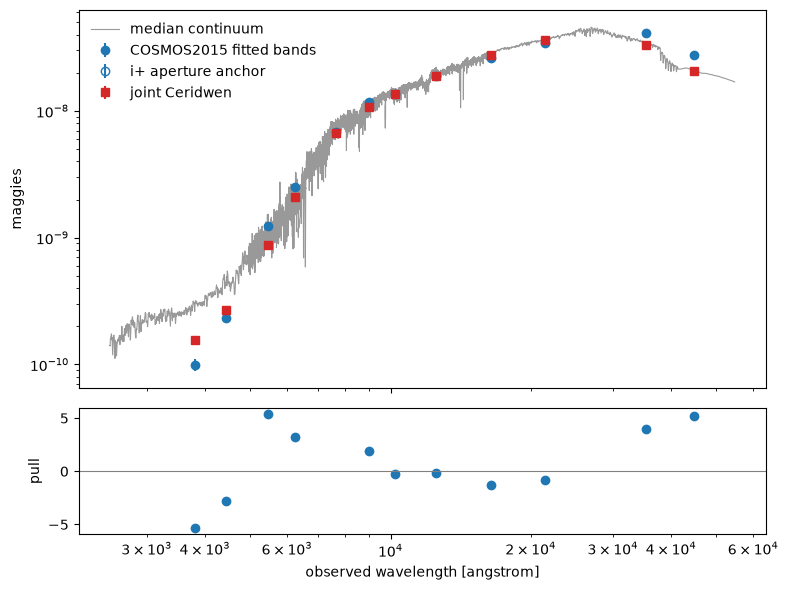

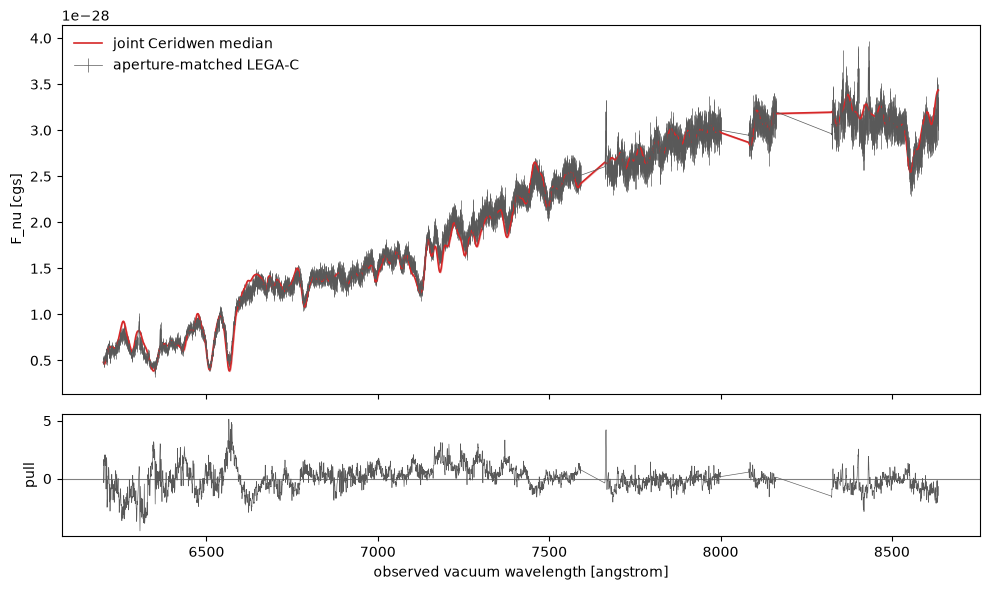

photometry chi2/datum: 11.44
spectrum chi2/bin: 1.09
joint chi2/datum: 1.13
sampled calibration floor: 4.66%
post-hoc calibrated spectrum chi2/bin: 0.96
post-hoc Chebyshev coefficients: [ 0.97301601  0.12098563 -0.03275674  0.07217384]


In [12]:
def posterior_batch(samples, model, count):
    total = len(next(iter(samples.values())))
    indices = np.linspace(0, total - 1, min(count, total), dtype=int)
    batch = {}
    for name, parameter_template in model.theta_init.items():
        values = np.asarray(samples[name])[indices]
        if np.shape(parameter_template) == (1,) and values.ndim == 1:
            values = values[:, None]
        batch[name] = jnp.asarray(values)
    return batch


joint_predictions = joint_model.predict_vmap(
    posterior_batch(joint_posterior, joint_model, 200)
)
phot_predictions = np.asarray(joint_predictions["photometry"])
spectrum_predictions = np.asarray(joint_predictions["spectrum"])
phot_q16, phot_q50, phot_q84 = np.percentile(
    phot_predictions,
    [16, 50, 84],
    axis=0,
)
spec_q16, spec_q50, spec_q84 = np.percentile(
    spectrum_predictions,
    [16, 50, 84],
    axis=0,
)

median_theta = {
    name: jnp.atleast_1d(np.median(np.asarray(values), axis=0))
    for name, values in joint_posterior.items()
}
physical_theta = joint_model.apply_transforms(median_theta)
continuum = (
    np.asarray(joint_csp.get_spectrum(physical_theta))
    * 10 ** float(median_theta["logmass"][0])
    * float(flux_factor_maggies(z_catalog))
    / CGS_FNU_PER_MAGGIE
)
continuum_wave = np.asarray(joint_csp.wave) * (1 + z_catalog)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)
wave_eff = np.asarray(phot_obs.wave_eff)
continuum_mask = (continuum_wave > 2500) & (continuum_wave < 55000)
axes[0].plot(
    continuum_wave[continuum_mask],
    continuum[continuum_mask],
    color="0.6",
    lw=0.8,
    label="median continuum",
)
axes[0].errorbar(
    wave_eff[phot_fit_mask],
    phot_flux[phot_fit_mask],
    yerr=phot_uncertainty[phot_fit_mask],
    fmt="o",
    color="tab:blue",
    label="COSMOS2015 fitted bands",
)
axes[0].errorbar(
    wave_eff[I_FILTER_INDEX],
    phot_flux[I_FILTER_INDEX],
    yerr=phot_uncertainty[I_FILTER_INDEX],
    fmt="o",
    markerfacecolor="none",
    color="tab:blue",
    label="i+ aperture anchor",
)
axes[0].errorbar(
    wave_eff,
    phot_q50,
    yerr=[phot_q50 - phot_q16, phot_q84 - phot_q50],
    fmt="s",
    color="tab:red",
    label="joint Ceridwen",
)
axes[0].set(xscale="log", yscale="log", ylabel="maggies")
axes[0].legend(frameon=False)
axes[1].axhline(0, color="0.5", lw=0.8)
axes[1].scatter(
    wave_eff[phot_fit_mask],
    (phot_flux[phot_fit_mask] - phot_q50[phot_fit_mask])
    / phot_uncertainty[phot_fit_mask],
    color="tab:blue",
)
axes[1].set(
    xscale="log",
    xlabel="observed wavelength [angstrom]",
    ylabel="pull",
)
plt.tight_layout()
plt.show()

calibration_fraction = float(
    np.exp(np.median(np.asarray(joint_posterior["log_f_calib"])))
)
effective_spec_uncertainty = np.hypot(
    spectrum_uncertainty,
    calibration_fraction * np.abs(spec_q50),
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)
axes[0].errorbar(
    spectrum_wave[spectrum_mask],
    spectrum_flux[spectrum_mask],
    yerr=effective_spec_uncertainty[spectrum_mask],
    fmt="-",
    lw=0.5,
    color="0.35",
    label="aperture-matched LEGA-C",
)
axes[0].plot(
    spectrum_wave[spectrum_mask],
    spec_q50[spectrum_mask],
    color="tab:red",
    lw=1.2,
    label="joint Ceridwen median",
)
axes[0].fill_between(
    spectrum_wave[spectrum_mask],
    spec_q16[spectrum_mask],
    spec_q84[spectrum_mask],
    color="tab:red",
    alpha=0.25,
)
axes[0].set(ylabel="F_nu [cgs]")
axes[0].legend(frameon=False)
axes[1].axhline(0, color="0.5", lw=0.8)
axes[1].plot(
    spectrum_wave[spectrum_mask],
    (spectrum_flux[spectrum_mask] - spec_q50[spectrum_mask])
    / effective_spec_uncertainty[spectrum_mask],
    lw=0.45,
    color="0.35",
)
axes[1].set(xlabel="observed vacuum wavelength [angstrom]", ylabel="pull")
plt.tight_layout()
plt.show()

phot_chi2 = np.sum(
    (
        (phot_flux[phot_fit_mask] - phot_q50[phot_fit_mask])
        / phot_uncertainty[phot_fit_mask]
    )
    ** 2
)
spectrum_chi2 = np.sum(
    (
        (spectrum_flux[spectrum_mask] - spec_q50[spectrum_mask])
        / effective_spec_uncertainty[spectrum_mask]
    )
    ** 2
)
calibration_coefficients, calibrated_median = spectrum_obs.fit_polynomial_calibration(
    spec_q50, order=3
)
calibrated_effective_uncertainty = np.hypot(
    spectrum_uncertainty,
    calibration_fraction * np.abs(np.asarray(calibrated_median)),
)
calibrated_chi2 = np.sum(
    (
        (spectrum_flux[spectrum_mask] - np.asarray(calibrated_median)[spectrum_mask])
        / calibrated_effective_uncertainty[spectrum_mask]
    )
    ** 2
)
joint_chi2 = phot_chi2 + spectrum_chi2
joint_points = phot_obs.ndof + spectrum_obs.ndof

print(f"photometry chi2/datum: {phot_chi2 / phot_obs.ndof:.2f}")
print(f"spectrum chi2/bin: {spectrum_chi2 / spectrum_obs.ndof:.2f}")
print(f"joint chi2/datum: {joint_chi2 / joint_points:.2f}")
print(f"sampled calibration floor: {100 * calibration_fraction:.2f}%")
print(
    f"post-hoc calibrated spectrum chi2/bin: {calibrated_chi2 / spectrum_obs.ndof:.2f}"
)
print(f"post-hoc Chebyshev coefficients: {calibration_coefficients}")

## Full native-spectrum comparison

- Show every native pixel used by the joint likelihood.
- Compare high-resolution absorption structure and residuals.

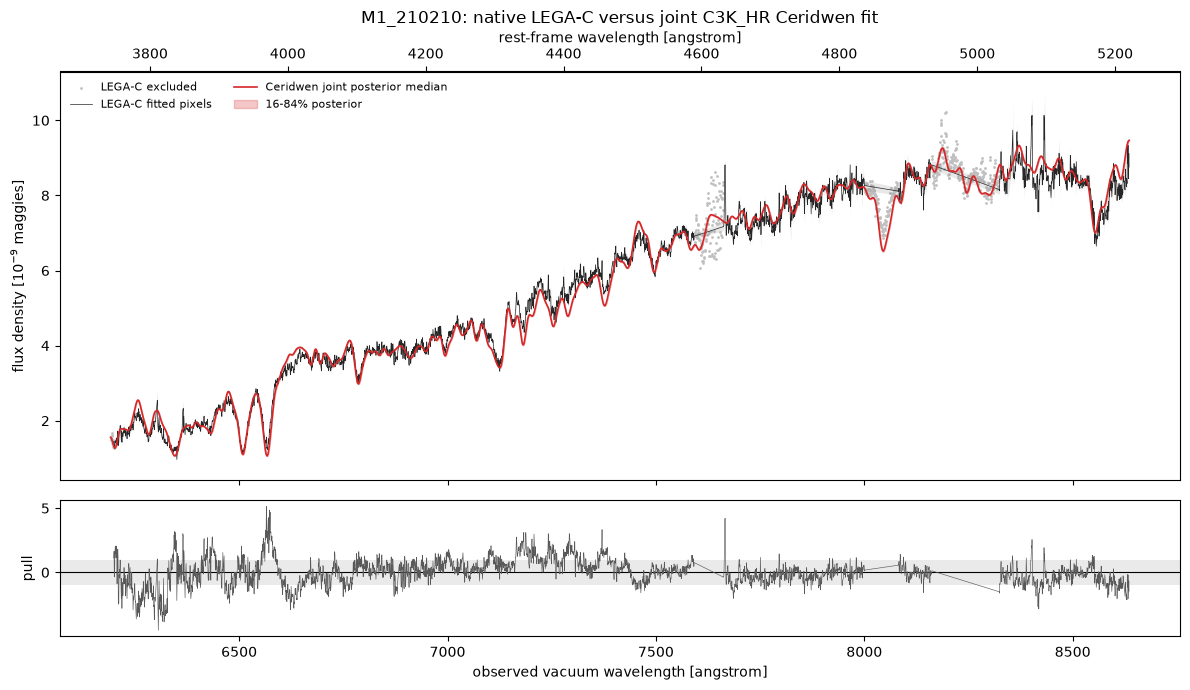

native valid pixels shown: 4053
native residual pixels after masks: 3523
native spectrum is the fitted high-resolution likelihood


In [13]:
native_plot_flux = spectrum_flux
native_plot_uncertainty = spectrum_uncertainty
native_fit_mask = spectrum_mask
native_q16, native_q50, native_q84 = spec_q16, spec_q50, spec_q84
native_effective_uncertainty = np.hypot(
    native_plot_uncertainty,
    calibration_fraction * np.abs(native_q50),
)
native_excluded_mask = native_valid & ~native_fit_mask
native_plot_scale = 1e9 / CGS_FNU_PER_MAGGIE

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)
axes[0].scatter(
    wave_vacuum[native_excluded_mask],
    native_plot_flux[native_excluded_mask] * native_plot_scale,
    s=4,
    color="0.75",
    linewidths=0,
    label="LEGA-C excluded",
    rasterized=True,
)
axes[0].fill_between(
    wave_vacuum[native_fit_mask],
    (native_plot_flux[native_fit_mask] - native_plot_uncertainty[native_fit_mask])
    * native_plot_scale,
    (native_plot_flux[native_fit_mask] + native_plot_uncertainty[native_fit_mask])
    * native_plot_scale,
    color="0.5",
    alpha=0.18,
    linewidth=0,
)
axes[0].plot(
    wave_vacuum[native_fit_mask],
    native_plot_flux[native_fit_mask] * native_plot_scale,
    color="0.15",
    lw=0.5,
    label="LEGA-C fitted pixels",
    rasterized=True,
)
axes[0].plot(
    wave_vacuum[native_valid],
    native_q50[native_valid] * native_plot_scale,
    color="tab:red",
    lw=1.2,
    label="Ceridwen joint posterior median",
)
axes[0].fill_between(
    wave_vacuum[native_valid],
    native_q16[native_valid] * native_plot_scale,
    native_q84[native_valid] * native_plot_scale,
    color="tab:red",
    alpha=0.25,
    label="16-84% posterior",
)
axes[0].set(ylabel=r"flux density [$10^{-9}$ maggies]")
axes[0].set_title(
    "M1_210210: native LEGA-C versus joint C3K_HR Ceridwen fit"
)
axes[0].legend(frameon=False, ncol=2, fontsize=8)
axes[1].axhspan(-1, 1, color="0.85", alpha=0.55, linewidth=0)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].plot(
    wave_vacuum[native_fit_mask],
    (native_plot_flux[native_fit_mask] - native_q50[native_fit_mask])
    / native_effective_uncertainty[native_fit_mask],
    color="0.35",
    lw=0.45,
    rasterized=True,
)
axes[1].set(
    xlabel="observed vacuum wavelength [angstrom]",
    ylabel="pull",
)
secondary_axis = axes[0].secondary_xaxis(
    "top",
    functions=(
        lambda observed: observed / (1 + z_catalog),
        lambda rest: rest * (1 + z_catalog),
    ),
)
secondary_axis.set_xlabel("rest-frame wavelength [angstrom]")
plt.tight_layout()
plt.show()

print(f"native valid pixels shown: {native_valid.sum()}")
print(f"native residual pixels after masks: {native_fit_mask.sum()}")
print("native spectrum is the fitted high-resolution likelihood")

## Population summary

- Derive mass-weighted age from every sampled nonparametric SFH.
- Report chemistry, dust, mass, calibration, and SFH uncertainty.

,parameter,median,minus,plus
0,logmass,11.473615,0.006476,0.007060
1,Z,-1.250599,0.016104,0.012537
2,afe,0.008072,0.005758,0.009187
3,diffuse_ta...,0.307248,0.010361,0.007318
4,fractional...,0.046622,0.000673,0.001050
5,mass-weigh...,4.454805,0.056042,0.085500


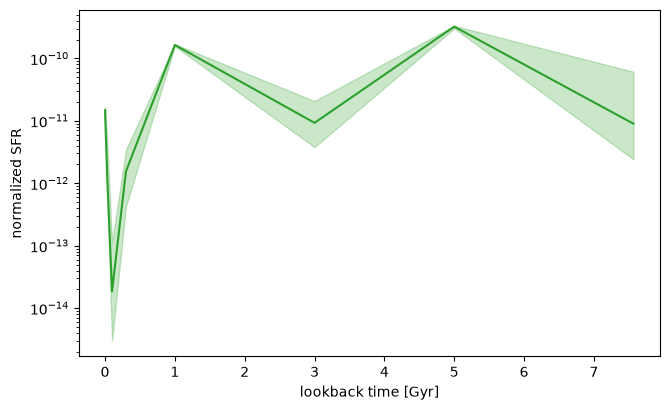

joint redshift fixed at 0.6542
fixed spectrum aperture transfer: 0.7092
joint fit status: diagnostics passed


In [14]:
def derived_sfh(samples, count=400):
    total = len(samples["logsfr_ratios"])
    indices = np.linspace(0, total - 1, min(count, total), dtype=int)
    histories = []
    ages = []
    for index in indices:
        ratios = np.asarray(samples["logsfr_ratios"])[index]
        history = np.asarray(
            logsfr_ratios_to_sfh(
                ratios,
                sfh_times_yr=lookback_template * 1e9,
            )
        )
        bin_mass = 0.5 * (history[:-1] + history[1:]) * np.diff(lookback_template) * 1e9
        bin_age = 0.5 * (lookback_template[:-1] + lookback_template[1:])
        histories.append(history)
        ages.append(np.sum(bin_mass * bin_age) / np.sum(bin_mass))
    return np.asarray(histories), np.asarray(ages)


joint_histories, joint_ages = derived_sfh(joint_posterior)
summary_rows = []
for parameter in ["logmass", "Z", "afe", "diffuse_tau_kc"]:
    q16, q50, q84 = np.percentile(
        joint_posterior[parameter],
        [16, 50, 84],
    )
    summary_rows.append(
        {
            "parameter": parameter,
            "median": q50,
            "minus": q50 - q16,
            "plus": q84 - q50,
        }
    )
q16, q50, q84 = np.percentile(
    np.exp(np.asarray(joint_posterior["log_f_calib"])),
    [16, 50, 84],
)
summary_rows.append(
    {
        "parameter": "fractional calibration floor",
        "median": q50,
        "minus": q50 - q16,
        "plus": q84 - q50,
    }
)
q16, q50, q84 = np.percentile(joint_ages, [16, 50, 84])
summary_rows.append(
    {
        "parameter": "mass-weighted age [Gyr]",
        "median": q50,
        "minus": q50 - q16,
        "plus": q84 - q50,
    }
)
summary = pd.DataFrame(summary_rows)
display(summary)

q16, q50, q84 = np.percentile(joint_histories, [16, 50, 84], axis=0)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(lookback_template, q50, color="tab:green")
ax.fill_between(
    lookback_template,
    q16,
    q84,
    color="tab:green",
    alpha=0.25,
)
ax.set(
    yscale="log",
    xlabel="lookback time [Gyr]",
    ylabel="normalized SFR",
)
plt.show()

print(f"joint redshift fixed at {z_catalog:.4f}")
print(f"fixed spectrum aperture transfer: {aperture_transfer:.4f}")
print(f"joint fit status: {joint_status}")

## Interpretation

- Joint constraints remain one-object exploratory evidence.
- The i+ anchor is excluded from the joint likelihood.
- The fixed aperture transfer remains a model assumption.
- Do not propagate this age into cosmological inference yet.